<a href="https://colab.research.google.com/github/maierav/claupenscope/blob/main/notebooks/rf_sub830794_probes_ABCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Receptive-field mapping — sub-830794, four-probe Neuropixels session

**Data.** OpenScope Predictive Processing dandiset 001637. Single recording session: `sub-830794_ses-ecephys-830794-2026-01-26-12-02-05_ecephys.nwb` (asset `a2cb56ec-5fc9-44d2-9197-038c4bb7ced6`). Four Neuropixels 1.0 probes (A, B, C, D) recorded simultaneously.

**Stimulus.** Sparse-noise / grating patches presented in the `rf_mapping` block at fixed (azimuth, elevation) positions on a regular grid.

**Analysis.** SUA passing `default_qc` are split by probe. For each unit we extract spike-time PSTHs aligned to stimulus onset, compute the baseline-subtracted firing rate at every grid position, and aggregate per probe.

**Figures.**
1. Population PSTH at each unit's preferred position, one panel per probe.
2. Best-tuned individual RF maps per probe (top *N*).
3. RF-centre azimuth/elevation distribution per probe.
4. Per-probe summary: unit count, visually responsive fraction, peak-rate distribution.

All figures are rendered at 300 dpi with consistent serif typography for direct inclusion in figures.

In [25]:
# Install dependencies (run once per Colab session). Skip in a local venv that has these.
!pip install -q git+https://github.com/maierav/claupenscope.git \
    dandi remfile h5py pynwb scipy matplotlib numpy pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [26]:
import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from scipy.ndimage import gaussian_filter

from openscope_pp.loaders.streaming import open_nwb
from openscope_pp.loaders.trials import load_trials

# ── Publication style ────────────────────────────────────────────────
# Tight, neutral, print-ready defaults. Use one consistent serif and
# small, legible tick/label sizes; render at high DPI.
mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Bitstream Vera Serif", "Liberation Serif", "serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 9.5,
    "axes.labelsize": 10,
    "axes.titlesize": 10.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "legend.fontsize": 8.0,
    "legend.frameon": False,
})

# ── Constants ────────────────────────────────────────────────────────
ASSET_ID  = "a2cb56ec-5fc9-44d2-9197-038c4bb7ced6"   # sub-830794, 2026-01-26

# Probe identities (PROBES, PROBE_LABELS, PROBE_COLOR) are populated
# AFTER we open the NWB, because the literal device_name strings
# differ between subjects/releases (probeA / Probe A / imec0 / ...).
# A four-colour Wong palette is reserved here and assigned by sort
# order over whatever device_name values actually appear.
PROBE_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7",
                  "#F0E442", "#56B4E9", "#E69F00", "#999999"]

# RF response & baseline windows (s, relative to stimulus onset)
RF_WIN     = (-0.30, 0.50)
BL_WIN     = (-0.20, 0.00)
RESP_WIN   = (0.03, 0.20)   # short, ecephys-appropriate
BIN_SIZE   = 0.010          # 10 ms — fine enough for fast onsets
RF_SMOOTH  = 0.8            # Gaussian σ in grid cells for visualisation
VIS_THR    = 5.0            # peak Δfiring-rate threshold for "visual" (spk/s)
N_TOP      = 6              # number of top RF examples per probe

print("Style + constants set.")

Style + constants set.


## 1. Open NWB and inventory probes

Stream the NWB lazily (no full download), pull the `units` table once, and group SUA by probe via the `device_name` column.

In [ ]:
def decode_str(arr):
    "Decode bytes/object string columns to a clean unicode array."
    if arr.dtype.kind in ("S", "O"):
        return np.array([v.decode() if isinstance(v, bytes) else str(v) for v in arr])
    return arr

print("Streaming NWB...")
t0 = time.time()
handle = open_nwb(ASSET_ID)
trials = load_trials(handle)
h5     = handle.h5
print(f"  Opened in {time.time()-t0:.1f} s")

# ── RF mapping trials ────────────────────────────────────────────────
rf_trials = trials[trials["block_kind"] == "rf_mapping"].copy()
xs_grid   = np.sort(rf_trials["x"].dropna().unique())
ys_grid   = np.sort(rf_trials["y"].dropna().unique())
print(f"  RF block: {len(rf_trials)} trials  ·  grid {len(xs_grid)}×{len(ys_grid)}  "
      f"(az {xs_grid[0]:.0f}…{xs_grid[-1]:.0f}°, el {ys_grid[0]:.0f}…{ys_grid[-1]:.0f}°)")

# ── Units table ──────────────────────────────────────────────────────
units_grp     = h5["units"]
decoder_label = decode_str(units_grp["decoder_label"][:])
default_qc    = units_grp["default_qc"][:].astype(bool)
device_name   = decode_str(units_grp["device_name"][:])
spike_times   = units_grp["spike_times"][:]
spk_index     = units_grp["spike_times_index"][:]

is_sua = (decoder_label == "sua") & default_qc
print(f"  Units total: {len(decoder_label)}  ·  SUA + default_qc: {is_sua.sum()}")

# ── Per-unit depth lookup (peak_channel_id → electrodes.rel_y) ───────
def _electrodes_rel_y(h5):
    "Locate the electrodes table and return id → rel_y (µm)."
    candidates = ["general/extracellular_ephys/electrodes", "electrodes"]
    for path in candidates:
        if path not in h5: continue
        g = h5[path]
        if "id" not in g: continue
        ids = np.asarray(g["id"][:]).astype(int)
        for ykey in ("rel_y", "y", "ypos", "vertical_position"):
            if ykey in g:
                return dict(zip(ids.tolist(), np.asarray(g[ykey][:]).astype(float).tolist()))
    return {}

id_to_y = _electrodes_rel_y(h5)
if "peak_channel_id" in units_grp and id_to_y:
    pk_ch = np.asarray(units_grp["peak_channel_id"][:]).astype(int)
    unit_depth_um = np.array([id_to_y.get(int(c), np.nan) for c in pk_ch])
else:
    unit_depth_um = np.full(len(decoder_label), np.nan, dtype=float)
print(f"  Depth lookup: {int(np.isfinite(unit_depth_um).sum())}/{len(unit_depth_um)} units have rel_y")

# Auto-detect the probe names from the file. Some sessions use
# "probeA"…"probeD"; others "Probe A", "imec0", etc. Whatever the
# strings are, we keep them as the canonical IDs and assign labels
# / colours by sort order.
probes_in_session = sorted(np.unique(device_name))
print(f"  Distinct device_name values: {probes_in_session}")

def _label_for(name, idx):
    # If the name ends in a single letter, use "Probe X"; otherwise
    # show the raw name so the user knows what is in the file.
    tail = name.strip()[-1]
    return f"Probe {tail.upper()}" if tail.isalpha() and len(name.strip()) >= 2 \
           else name

PROBES       = list(probes_in_session)
PROBE_LABELS = {p: _label_for(p, i) for i, p in enumerate(PROBES)}
PROBE_COLOR  = {p: PROBE_PALETTE[i % len(PROBE_PALETTE)] for i, p in enumerate(PROBES)}

# Map probe → SUA+QC unit indices.
probe_units = {p: np.where((device_name == p) & is_sua)[0] for p in PROBES}
for p in PROBES:
    print(f"   {PROBE_LABELS[p]:14s}  device_name = {p!r:18s}  n_SUA = {len(probe_units[p])}")

# Sanity: refuse to proceed with zero usable units everywhere — would
# silently produce empty figures otherwise.
if not any(len(probe_units[p]) for p in PROBES):
    raise RuntimeError("No SUA + default_qc units found on any probe — "
                       "check decoder_label / device_name fields.")

## 2. RF pipeline

For each unit we (i) bin spikes into 10 ms windows around every RF trial onset, (ii) compute baseline-subtracted firing-rate per stimulus position, and (iii) build a 2-D RF map. We also keep the per-trial unit×time tensor so we can plot a population PSTH at each unit's preferred position.

In [ ]:
def bin_spikes(uid_arr, spikes, index, onsets, window, bin_size):
    """Spike binning → (n_trials, n_units, n_bins) firing rates (spk/s)."""
    pre, post = window
    edges   = np.arange(pre, post + bin_size, bin_size)
    centers = 0.5 * (edges[:-1] + edges[1:])
    out = np.zeros((len(onsets), len(uid_arr), len(centers)), dtype=np.float32)
    for j, uid in enumerate(uid_arr):
        i0 = int(index[uid - 1]) if uid > 0 else 0
        s  = spikes[i0:int(index[uid])]
        if not len(s):
            continue
        for i, t0 in enumerate(onsets):
            lo = int(np.searchsorted(s, t0 + pre))
            hi = int(np.searchsorted(s, t0 + post))
            if lo < hi:
                cnt, _ = np.histogram(s[lo:hi] - t0, bins=edges)
                out[i, j, :] = cnt / bin_size
    return out, centers

def compute_rf_maps(arr, t_centers, x_vals, y_vals, x_trial, y_trial,
                    resp_win=RESP_WIN, bl_win=BL_WIN):
    """Per-unit RF map = mean(resp_win) − mean(bl_win), per (x, y) cell.
    Returns rf_map of shape (n_units, n_y, n_x) in spk/s.
    """
    rsp = (t_centers >= resp_win[0]) & (t_centers < resp_win[1])
    bl  = (t_centers >= bl_win[0])   & (t_centers < bl_win[1])
    n_units = arr.shape[1]
    rf = np.zeros((n_units, len(y_vals), len(x_vals)), dtype=np.float32)
    for xi, x in enumerate(x_vals):
        for yi, y in enumerate(y_vals):
            m = (x_trial == x) & (y_trial == y)
            if not m.any():
                continue
            rf[:, yi, xi] = (np.nanmean(arr[m][:, :, rsp], axis=(0, 2))
                            - np.nanmean(arr[m][:, :, bl ], axis=(0, 2)))
    return rf

def pref_pos_psth(arr, t_centers, rf_smoothed, x_vals, y_vals, x_trial, y_trial):
    """Per-unit PSTH at its own preferred (x, y); return mean ± SEM across units."""
    n_units, _, n_t = arr.shape[1], None, arr.shape[2]
    out = np.full((n_units, n_t), np.nan, dtype=np.float32)
    for u in range(n_units):
        yi, xi = np.unravel_index(np.argmax(rf_smoothed[u]), rf_smoothed[u].shape)
        m = (x_trial == x_vals[xi]) & (y_trial == y_vals[yi])
        if m.any():
            out[u, :] = np.nanmean(arr[m, u, :], axis=0)
    mn = np.nanmean(out, axis=0)
    n  = np.sum(np.isfinite(out), axis=0).clip(1)
    se = np.nanstd(out, axis=0) / np.sqrt(n)
    return mn, se

x_trial = rf_trials["x"].values
y_trial = rf_trials["y"].values
onsets  = rf_trials["start_time"].values

results = {}
for p in PROBES:
    uid_arr = probe_units[p]
    if len(uid_arr) == 0:
        print(f"  {PROBE_LABELS[p]}: no SUA, skipping")
        continue
    print(f"Binning spikes — {PROBE_LABELS[p]} ({len(uid_arr)} units)... ", end="", flush=True)
    t0 = time.time()
    arr, t_centers = bin_spikes(uid_arr, spike_times, spk_index, onsets, RF_WIN, BIN_SIZE)
    print(f"{time.time()-t0:.0f} s")
    rf_raw = compute_rf_maps(arr, t_centers, xs_grid, ys_grid, x_trial, y_trial)
    rf_sm  = np.array([gaussian_filter(rf_raw[u], RF_SMOOTH) for u in range(rf_raw.shape[0])])
    flat   = rf_sm.reshape(rf_sm.shape[0], -1)
    peak   = flat.max(axis=1) if flat.size else np.zeros(rf_sm.shape[0], dtype=np.float32)
    mn, se = pref_pos_psth(arr, t_centers, rf_sm, xs_grid, ys_grid, x_trial, y_trial)
    results[p] = dict(uids=uid_arr, t=t_centers, rf_raw=rf_raw, rf_sm=rf_sm,
                      peak=peak, psth_mn=mn, psth_se=se,
                      depth=unit_depth_um[uid_arr])
    print(f"   peak Δfr  median = {np.median(peak):.2f} spk/s  ·  "
          f"visually responsive (peak ≥ {VIS_THR:g}): "
          f"{int((peak >= VIS_THR).sum())}/{len(peak)}")

handle.close()
print("\nPipeline complete.")

## Figure 1 — Population PSTH at preferred position

Each unit contributes only the trials at its own preferred (azimuth, elevation); the panel-average therefore reflects the canonical visual response shape per probe rather than a position-blurred average.

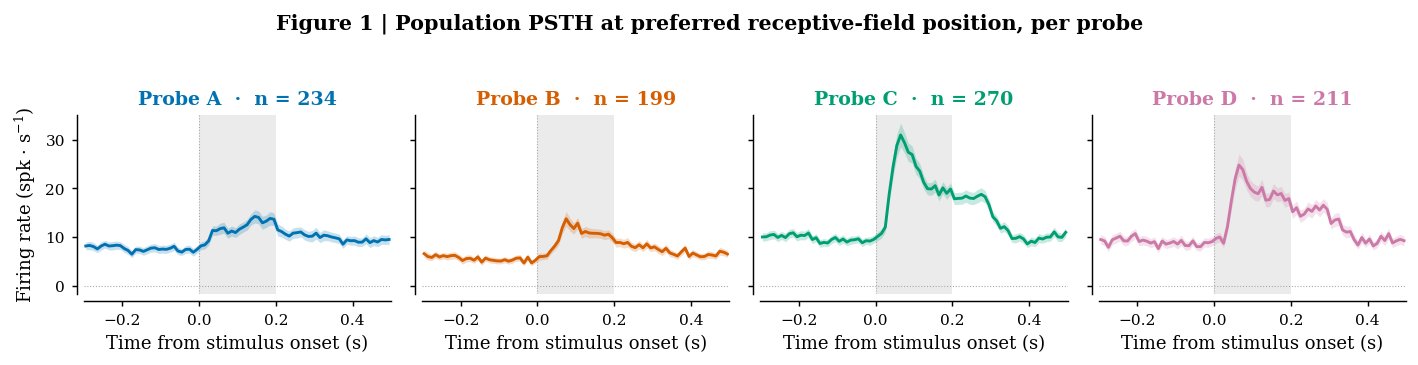

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(11.0, 2.6), sharex=True, sharey=True)
for ax, p in zip(axes, PROBES):
    if p not in results:
        ax.axis("off"); continue
    r = results[p]
    c = PROBE_COLOR[p]
    ax.axvspan(0, RESP_WIN[1], color="0.92", lw=0)
    ax.axhline(0, color="0.65", lw=0.6, ls=":")
    ax.axvline(0, color="0.65", lw=0.6, ls=":")
    ax.fill_between(r["t"], r["psth_mn"] - r["psth_se"], r["psth_mn"] + r["psth_se"],
                    color=c, alpha=0.22, lw=0)
    ax.plot(r["t"], r["psth_mn"], color=c, lw=1.6)
    ax.set_title(f"{PROBE_LABELS[p]}  ·  n = {len(r['uids'])}", color=c, fontweight="bold")
    ax.set_xlim(RF_WIN)
axes[0].set_ylabel("Firing rate (spk · s$^{-1}$)")
for ax in axes:
    ax.set_xlabel("Time from stimulus onset (s)")
    ax.spines["left"].set_position(("outward", 4))
    ax.spines["bottom"].set_position(("outward", 4))
fig.suptitle("Figure 1 | Population PSTH at preferred receptive-field position, per probe",
             y=1.06, fontweight="bold")
fig.tight_layout()
fig.savefig("fig1_rf_population_psth.png")
plt.show()

## Figure 2 — Best receptive fields per probe

Top *N* = 6 individual SUA per probe, ranked by smoothed peak response. Maps are Gaussian-smoothed (σ = 0.8 grid cells) and shown on a symmetric diverging colour scale. The colour scale is set per panel from the 99-percentile to make weak fields visible while keeping signs honest.

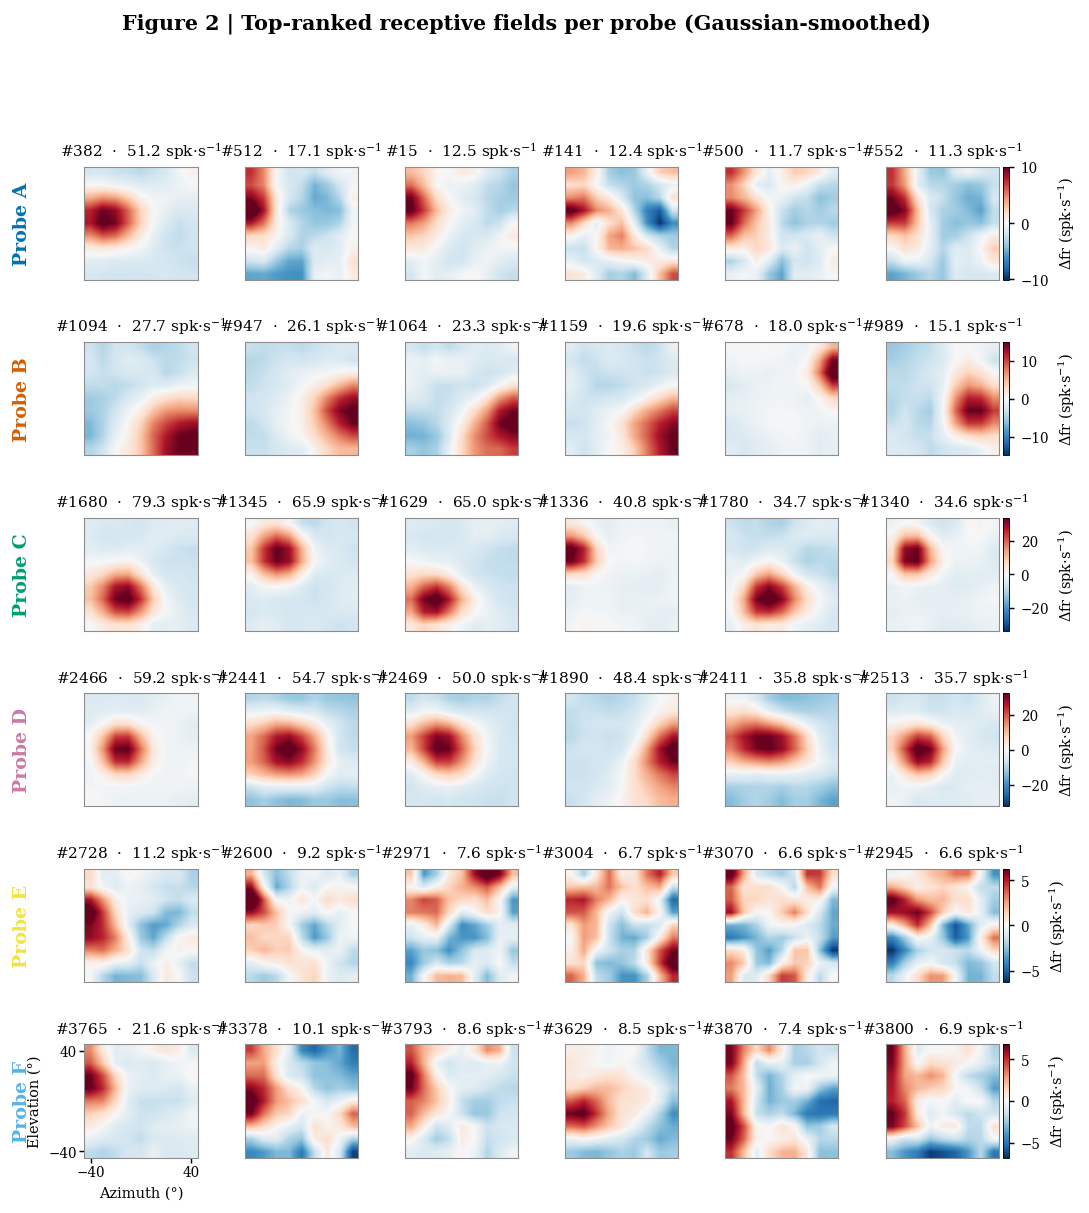

In [30]:
extent = [xs_grid[0] - 5, xs_grid[-1] + 5, ys_grid[0] - 5, ys_grid[-1] + 5]

fig, axes = plt.subplots(len(PROBES), N_TOP, figsize=(N_TOP * 1.55, len(PROBES) * 1.65),
                          gridspec_kw=dict(wspace=0.18, hspace=0.55))
for row, p in enumerate(PROBES):
    r = results.get(p)
    if r is None:
        for ax in axes[row]:
            ax.axis("off")
        continue
    if r["peak"].size == 0:
        for ax in axes[row]:
            ax.axis("off")
        continue
    order = np.argsort(r["peak"])[::-1][:N_TOP]
    # row label
    axes[row, 0].annotate(PROBE_LABELS[p], xy=(-0.55, 0.5),
                          xycoords="axes fraction", ha="center", va="center",
                          rotation=90, fontweight="bold", color=PROBE_COLOR[p],
                          fontsize=10.5)
    for col, u in enumerate(order):
        ax = axes[row, col]
        m  = r["rf_sm"][u]
        absm = np.abs(m)
        vm   = max(np.percentile(absm, 99) if absm.size else 0.0, 1e-3)
        im = ax.imshow(m, origin="lower", cmap="RdBu_r",
                       extent=extent, vmin=-vm, vmax=vm, aspect="equal",
                       interpolation="bilinear")
        ax.set_title(f"#{r['uids'][u]}  ·  {r['peak'][u]:.1f} spk·s$^{{-1}}$",
                     fontsize=8.5)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(True); s.set_linewidth(0.6); s.set_color("0.55")
    # colour bar at the rightmost cell of each row
    cb = fig.colorbar(im, ax=axes[row, -1], fraction=0.05, pad=0.03)
    cb.outline.set_linewidth(0.5)
    cb.ax.tick_params(labelsize=7.5)
    cb.set_label("Δfr (spk·s$^{-1}$)", fontsize=8)

# Shared axis annotation in lower-left tile
axes[-1, 0].set_xticks([xs_grid[0], xs_grid[-1]])
axes[-1, 0].set_yticks([ys_grid[0], ys_grid[-1]])
axes[-1, 0].tick_params(length=2.5, labelsize=7.5, pad=1.5)
axes[-1, 0].set_xlabel("Azimuth (°)", fontsize=8)
axes[-1, 0].set_ylabel("Elevation (°)", fontsize=8)

fig.suptitle("Figure 2 | Top-ranked receptive fields per probe (Gaussian-smoothed)",
             y=1.0, fontweight="bold")
fig.savefig("fig2_rf_gallery_per_probe.png")
plt.show()

## Figure 3 — Receptive-field centre coverage

Centre = location of the smoothed RF peak per visually responsive unit (peak ≥ 5 spk·s⁻¹). Marginal histograms show the azimuth and elevation distributions per probe.

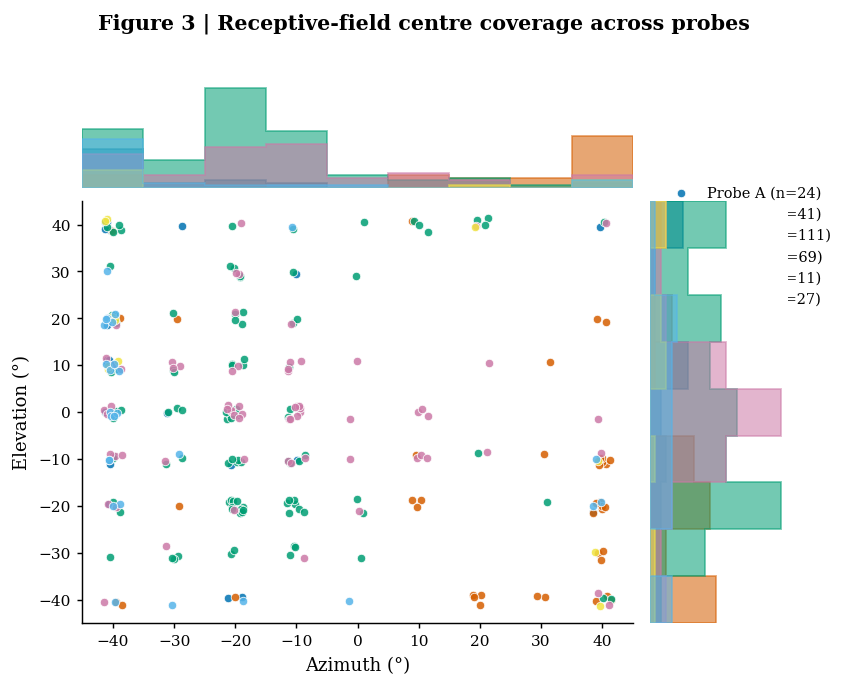


Visually responsive units per probe:
  Probe A     24 / 234  (10 %)
  Probe B     41 / 199  (21 %)
  Probe C    111 / 270  (41 %)
  Probe D     69 / 211  (33 %)
  Probe E     11 / 312  (4 %)
  Probe F     27 / 350  (8 %)


In [31]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(7.0, 5.4))
gs  = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
               hspace=0.05, wspace=0.05, figure=fig)
ax_main = fig.add_subplot(gs[1, 0])
ax_top  = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_rgt  = fig.add_subplot(gs[1, 1], sharey=ax_main)

def _bin_edges(g):
    if len(g) < 2:
        # Single-position grid: pick a 5° symmetric edge.
        return np.array([g[0]-2.5, g[0]+2.5]) if len(g) else np.array([-2.5, 2.5])
    step = float(g[1] - g[0])
    return np.append(g - step/2, g[-1] + step/2)
x_edges = _bin_edges(xs_grid)
y_edges = _bin_edges(ys_grid)

summary_rows = []
for p in PROBES:
    r = results.get(p)
    if r is None: continue
    vis = np.where(r["peak"] >= VIS_THR)[0]
    if not len(vis):
        summary_rows.append((p, len(r["uids"]), 0)); continue
    cx, cy = [], []
    for u in vis:
        yi, xi = np.unravel_index(np.argmax(r["rf_sm"][u]), r["rf_sm"][u].shape)
        cx.append(xs_grid[xi]); cy.append(ys_grid[yi])
    cx = np.array(cx) + np.random.uniform(-1.5, 1.5, len(cx))   # slight jitter for visibility
    cy = np.array(cy) + np.random.uniform(-1.5, 1.5, len(cy))
    ax_main.scatter(cx, cy, s=22, color=PROBE_COLOR[p], edgecolor="white",
                    linewidth=0.5, alpha=0.85, label=f"{PROBE_LABELS[p]} (n={len(vis)})")
    ax_top.hist(cx, bins=x_edges, color=PROBE_COLOR[p], alpha=0.55, histtype="stepfilled",
                edgecolor=PROBE_COLOR[p], lw=0.8)
    ax_rgt.hist(cy, bins=y_edges, color=PROBE_COLOR[p], alpha=0.55, histtype="stepfilled",
                edgecolor=PROBE_COLOR[p], lw=0.8, orientation="horizontal")
    summary_rows.append((p, len(r["uids"]), len(vis)))

ax_main.set_xlabel("Azimuth (°)")
ax_main.set_ylabel("Elevation (°)")
ax_main.set_xlim(extent[0], extent[1])
ax_main.set_ylim(extent[2], extent[3])
ax_main.legend(loc="upper left", bbox_to_anchor=(1.05, 1.05), borderaxespad=0)
for ax in (ax_top, ax_rgt):
    ax.tick_params(labelleft=False, labelbottom=False, length=0)
    for s in ax.spines.values():
        s.set_visible(False)
ax_top.set_yticks([]); ax_rgt.set_xticks([])
fig.suptitle("Figure 3 | Receptive-field centre coverage across probes",
             y=0.98, fontweight="bold")
fig.savefig("fig3_rf_centre_coverage.png")
plt.show()

print("\nVisually responsive units per probe:")
for p, n_all, n_vis in summary_rows:
    print(f"  {PROBE_LABELS[p]:9s}  {n_vis:3d} / {n_all:3d}  ({100*n_vis/max(n_all,1):.0f} %)")

## Figure 4 — Per-probe summary

Two complementary views: bar of unit yield (total SUA + responsive fraction) and a violin of peak-rate distribution per probe.

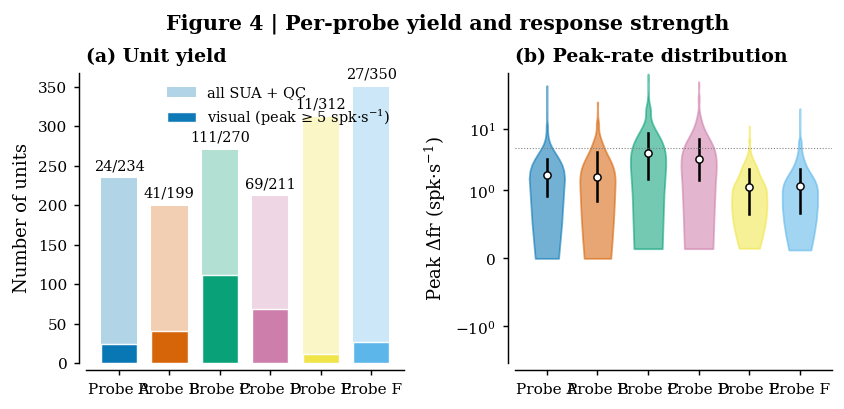

  probe  n_SUA  n_visual (≥5 spk/s)  peak median (spk/s)  peak P75 (spk/s)  peak max (spk/s)
Probe A    234                   24                 1.78              3.26             51.20
Probe B    199                   41                 1.66              4.21             27.72
Probe C    270                  111                 4.14              8.50             79.31
Probe D    211                   69                 3.24              6.93             59.22
Probe E    312                   11                 1.15              2.21             11.23
Probe F    350                   27                 1.17              2.25             21.58


In [32]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(7.4, 2.9),
                                  gridspec_kw=dict(wspace=0.35))

probes_ok = [p for p in PROBES if p in results]
x = np.arange(len(probes_ok))
n_total = np.array([len(results[p]["uids"]) for p in probes_ok])
n_vis   = np.array([(results[p]["peak"] >= VIS_THR).sum() for p in probes_ok])
colors  = [PROBE_COLOR[p] for p in probes_ok]

# (a) Yield bars
ax_a.bar(x, n_total, color=colors, alpha=0.30, edgecolor="none", width=0.72,
         label="all SUA + QC")
ax_a.bar(x, n_vis, color=colors, alpha=0.95, edgecolor="white", lw=0.8, width=0.72,
         label=f"visual (peak ≥ {VIS_THR:g} spk·s$^{{-1}}$)")
for xi, p in zip(x, probes_ok):
    ax_a.text(xi, n_total[xi] + max(n_total)*0.02,
              f"{n_vis[xi]}/{n_total[xi]}", ha="center", va="bottom", fontsize=8)
ax_a.set_xticks(x)
ax_a.set_xticklabels([PROBE_LABELS[p] for p in probes_ok], rotation=0)
ax_a.set_ylabel("Number of units")
ax_a.set_title("(a) Unit yield", loc="left", fontweight="bold")
ax_a.legend(loc="upper right")
ax_a.spines["left"].set_position(("outward", 4))
ax_a.spines["bottom"].set_position(("outward", 4))

# (b) Peak-rate violin
# Drop empty peak arrays — violinplot internally calls dataset.min()
# which raises 'zero-size array' on empty data.
viol = [(xi, results[p]["peak"], PROBE_COLOR[p])
        for xi, p in zip(x, probes_ok) if results[p]["peak"].size]
if viol:
    pos  = [v[0] for v in viol]
    vals_list = [v[1] for v in viol]
    cols = [v[2] for v in viol]
    parts = ax_b.violinplot(vals_list, positions=pos, widths=0.7,
                            showmeans=False, showmedians=False, showextrema=False)
    for body, c in zip(parts["bodies"], cols):
        body.set_facecolor(c); body.set_edgecolor(c); body.set_alpha(0.55)
    for xi, vals in zip(pos, vals_list):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        ax_b.plot([xi, xi], [q1, q3], color="black", lw=1.4)
        ax_b.plot(xi, med, "o", color="white", markersize=4, markeredgecolor="black",
                  markeredgewidth=0.8, zorder=5)
ax_b.axhline(VIS_THR, color="0.5", lw=0.6, ls=":")
ax_b.set_xticks(x)
ax_b.set_xticklabels([PROBE_LABELS[p] for p in probes_ok], rotation=0)
ax_b.set_ylabel("Peak Δfr (spk·s$^{-1}$)")
ax_b.set_yscale("symlog", linthresh=1.0)
ax_b.set_title("(b) Peak-rate distribution", loc="left", fontweight="bold")
ax_b.spines["left"].set_position(("outward", 4))
ax_b.spines["bottom"].set_position(("outward", 4))

fig.suptitle("Figure 4 | Per-probe yield and response strength", y=1.04, fontweight="bold")
fig.savefig("fig4_per_probe_summary.png")
plt.show()

# Numerical summary
rows = []
for p in probes_ok:
    pk = results[p]["peak"]
    rows.append({
        "probe": PROBE_LABELS[p],
        "n_SUA": len(pk),
        "n_visual (≥%g spk/s)" % VIS_THR: int((pk >= VIS_THR).sum()),
        "peak median (spk/s)": float(np.median(pk)) if pk.size else float("nan"),
        "peak P75 (spk/s)":    float(np.percentile(pk, 75)) if pk.size else float("nan"),
        "peak max (spk/s)":    float(np.max(pk)) if pk.size else float("nan"),
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

## Figure 5 — RFs organised by depth

Each probe occupies one quadrant. Within a quadrant, every row corresponds to an 80-µm depth bin on the probe shank (deepest at the bottom); columns hold the individual SUA whose peak channel falls in that bin. Each tile is a Gaussian-smoothed RF map (viridis, per-unit auto-scaled). Depth labels (µm, relative to the probe tip) sit on the leftmost column.

In [ ]:
from matplotlib.gridspec import GridSpec

DEPTH_BIN_UM = 80.0   # ~16-channel bin on Neuropixels 1.0 (20 µm pitch)

probes_for_depth = [p for p in PROBES if p in results][:4]

fig = plt.figure(figsize=(15.5, 13))
outer = GridSpec(2, 2, figure=fig, hspace=0.18, wspace=0.18,
                  left=0.05, right=0.99, top=0.93, bottom=0.03)
slots = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (sr, sc), p in zip(slots, probes_for_depth):
    r = results[p]
    depth = r.get("depth")
    rf_sm = r["rf_sm"]
    valid = np.isfinite(depth) if depth is not None else np.zeros(len(rf_sm), bool)
    if not valid.any():
        ax = fig.add_subplot(outer[sr, sc])
        ax.text(0.5, 0.5, f"{PROBE_LABELS[p]}\nno depth info",
                ha="center", va="center", color=PROBE_COLOR[p], fontweight="bold")
        ax.axis("off"); continue
    depth = depth[valid]; rf_sm = rf_sm[valid]

    d_lo = float(np.floor(depth.min() / DEPTH_BIN_UM) * DEPTH_BIN_UM)
    d_hi = float(np.ceil(depth.max()  / DEPTH_BIN_UM) * DEPTH_BIN_UM)
    edges = np.arange(d_lo, d_hi + DEPTH_BIN_UM, DEPTH_BIN_UM)
    n_bins = max(1, len(edges) - 1)
    bin_idx = np.clip(np.digitize(depth, edges) - 1, 0, n_bins - 1)
    bin_units = [np.where(bin_idx == b)[0] for b in range(n_bins)]
    max_per_bin = max(1, max((len(b) for b in bin_units), default=1))

    inner = outer[sr, sc].subgridspec(n_bins, max_per_bin,
                                      hspace=0.04, wspace=0.04)
    for plot_row, b_idx in enumerate(range(n_bins - 1, -1, -1)):
        b = bin_units[b_idx]
        for col in range(max_per_bin):
            ax = fig.add_subplot(inner[plot_row, col])
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(True); s.set_linewidth(0.3); s.set_color("0.55")
            if col < len(b):
                m = rf_sm[b[col]]
                vmax = max(np.percentile(m, 99) if m.size else 0.0, 1e-3)
                ax.imshow(m, origin="lower", cmap="viridis",
                          aspect="equal", interpolation="nearest",
                          vmin=0, vmax=vmax)
            else:
                for s in ax.spines.values(): s.set_visible(False)
            if col == 0:
                ax.set_ylabel(f"{int(edges[b_idx])}", fontsize=6, rotation=0,
                              va="center", ha="right", labelpad=6)

    bb = outer[sr, sc].get_position(fig)
    fig.text(bb.x0 + 0.006, bb.y1 - 0.012,
             PROBE_LABELS[p].split()[-1].upper(),
             fontsize=38, fontweight="bold", color=PROBE_COLOR[p],
             ha="left", va="top")

fig.suptitle("Figure 5 | Receptive fields organised by probe depth\n"
             "rows = 80 µm depth bins (deepest at bottom)  ·  columns = SUA in bin  ·  viridis = Δ firing rate",
             y=0.985, fontweight="bold")
fig.savefig("fig5_rf_by_depth.png")
plt.show()


---
All four figures are written to the working directory at 300 dpi and ready for direct inclusion in a manuscript:

* `fig1_rf_population_psth.png` — Figure 1
* `fig2_rf_gallery_per_probe.png` — Figure 2
* `fig3_rf_centre_coverage.png` — Figure 3
* `fig4_per_probe_summary.png` — Figure 4
* `fig5_rf_by_depth.png` — Figure 5 (RFs by probe depth)
